In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## **Loading dataset and preprocessing**

In [2]:
## link for dataset https://www.kaggle.com/datasets/sunilthite/text-document-classification-dataset?resource=download

df = pd.read_csv("df_file.csv")
df.head()

,Text,Label
0,Budget to set scene for election\n \n Gordon B...,0
1,Army chiefs in regiments decision\n \n Militar...,0
2,Howard denies split over ID cards\n \n Michael...,0
3,Observers to monitor UK election\n \n Minister...,0
4,Kilroy names election seat target\n \n Ex-chat...,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    2225 non-null   object
 1   Label   2225 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 34.9+ KB


In [4]:
df['Label'].value_counts()

Label
1    511
4    510
0    417
2    401
3    386
Name: count, dtype: int64

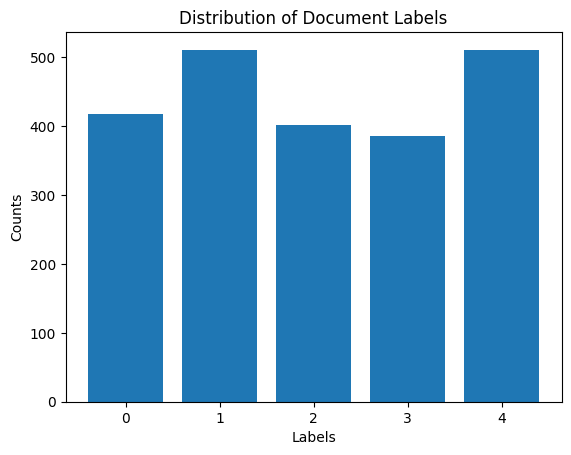

In [5]:
plt.bar(df['Label'].value_counts().index, df['Label'].value_counts().values)
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.title('Distribution of Document Labels')
plt.show()

In [6]:
df['Text'][0]

'Budget to set scene for election\n \n Gordon Brown will seek to put the economy at the centre of Labour\'s bid for a third term in power when he delivers his ninth Budget at 1230 GMT. He is expected to stress the importance of continued economic stability, with low unemployment and interest rates. The chancellor is expected to freeze petrol duty and raise the stamp duty threshold from Â£60,000. But the Conservatives and Lib Dems insist voters face higher taxes and more means-testing under Labour.\n \n Treasury officials have said there will not be a pre-election giveaway, but Mr Brown is thought to have about Â£2bn to spare.\n \n - Increase in the stamp duty threshold from Â£60,000 \n  - A freeze on petrol duty \n  - An extension of tax credit scheme for poorer families \n  - Possible help for pensioners The stamp duty threshold rise is intended to help first time buyers - a likely theme of all three of the main parties\' general election manifestos. Ten years ago, buyers had a much g

In [7]:
len(df['Text'][0].split())

538

In [8]:
### Tokenization

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha()]
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

In [9]:
df["cleaned_text"]= df["Text"].apply(preprocess_text)
df.head()

,Text,Label,cleaned_text
0,Budget to set scene for election\n \n Gordon B...,0,"[budget, set, scene, election, gordon, brown, ..."
1,Army chiefs in regiments decision\n \n Militar...,0,"[army, chiefs, regiments, decision, military, ..."
2,Howard denies split over ID cards\n \n Michael...,0,"[howard, denies, split, id, cards, michael, ho..."
3,Observers to monitor UK election\n \n Minister...,0,"[observers, monitor, uk, election, ministers, ..."
4,Kilroy names election seat target\n \n Ex-chat...,0,"[kilroy, names, election, seat, target, show, ..."


In [10]:
## Creating Vocabulary
vocab = set()
for tokens in df['cleaned_text']:
    vocab.update(tokens)

print(f'Vocabulary Size: {len(vocab)}')
word2idx = {word: idx+1 for idx, word in enumerate(vocab)}  # +1 for padding
word2idx['<PAD>'] = 0
idx2word = {idx: word for word, idx in word2idx.items()}

Vocabulary Size: 27206


In [11]:
word2idx

{'acquitted': 1,
 'neeson': 2,
 'pinsent': 3,
 'kilometre': 4,
 'shopping': 5,
 'vickerman': 6,
 'compostable': 7,
 'margaret': 8,
 'collapsed': 9,
 'troncon': 10,
 'deutschland': 11,
 'compatible': 12,
 'shum': 13,
 'rampersad': 14,
 'barnett': 15,
 'corr': 16,
 'conserve': 17,
 'saulnier': 18,
 'postulating': 19,
 'drainage': 20,
 'lembit': 21,
 'burnt': 22,
 'fortey': 23,
 'rental': 24,
 'packages': 25,
 'people': 26,
 'indirectly': 27,
 'downloadable': 28,
 'fallers': 29,
 'claimant': 30,
 'defacement': 31,
 'oblige': 32,
 'hms': 33,
 'mattresses': 34,
 'inching': 35,
 'talbot': 36,
 'jeers': 37,
 'laughter': 38,
 'recommissioning': 39,
 'mcpake': 40,
 'haunt': 41,
 'blizzard': 42,
 'astrazeneca': 43,
 'extremism': 44,
 'nous': 45,
 'condom': 46,
 'shark': 47,
 'buying': 48,
 'voter': 49,
 'suspected': 50,
 'cinematographer': 51,
 'obligation': 52,
 'blinkx': 53,
 'henry': 54,
 'case': 55,
 'either': 56,
 'broadside': 57,
 'tide': 58,
 'gail': 59,
 'effect': 60,
 'clans': 61,
 'ess

In [12]:
embedded_text_list = []

for tokens in df["cleaned_text"]:
    row_numbers = []          # this will store numbers for one row
    
    for word in tokens:
        row_numbers.append(word2idx[word])   # convert word → number
    
    embedded_text_list.append(row_numbers)

df["embedded_text"] = embedded_text_list

In [13]:
df.head()

,Text,Label,cleaned_text,embedded_text
0,Budget to set scene for election\n \n Gordon B...,0,"[budget, set, scene, election, gordon, brown, ...","[23099, 2137, 4705, 864, 24747, 21121, 3484, 1..."
1,Army chiefs in regiments decision\n \n Militar...,0,"[army, chiefs, regiments, decision, military, ...","[17244, 818, 18716, 11646, 15990, 818, 9502, 9..."
2,Howard denies split over ID cards\n \n Michael...,0,"[howard, denies, split, id, cards, michael, ho...","[21150, 12305, 25994, 19867, 11051, 1026, 2115..."
3,Observers to monitor UK election\n \n Minister...,0,"[observers, monitor, uk, election, ministers, ...","[26130, 14262, 25878, 864, 25980, 14572, 2155,..."
4,Kilroy names election seat target\n \n Ex-chat...,0,"[kilroy, names, election, seat, target, show, ...","[20392, 3606, 864, 12635, 9792, 17187, 22049, ..."


In [14]:
def one_hot_encode(tweet, word_to_index, vocab_size):
    encoding = np.zeros(vocab_size, dtype=int)
    for word in tweet:
        if word in word_to_index:  # Ignore words not in the vocabulary
            encoding[word_to_index[word]] = 1
    return encoding

In [15]:
X = np.array([one_hot_encode(tokens, word2idx, len(word2idx)) for tokens in df['cleaned_text']])
y = df['Label'].values
X.shape, y.shape

((2225, 27207), (2225,))

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1780, 27207), (445, 27207), (1780,), (445,))

In [17]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

# Step 3: Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    # "Support Vector Machine (SVM)": SVC(kernel='linear', probability=True),
    "Naive Bayes": MultinomialNB(),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    # "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Step 4: Train and evaluate each model
results = {}
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Predict on test set
    accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
    results[model_name] = accuracy  # Store accuracy for comparison
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

# Step 5: Display model performance comparison
print("\nModel Performance Comparison:")
for model_name, accuracy in results.items():
    print(f"{model_name}: {accuracy:.4f}")



Training Logistic Regression...
Logistic Regression Accuracy: 0.9685
              precision    recall  f1-score   support

           0       0.96      0.95      0.95        92
           1       0.99      0.98      0.98        98
           2       1.00      0.94      0.97        77
           3       0.94      0.99      0.96        76
           4       0.96      0.99      0.98       102

    accuracy                           0.97       445
   macro avg       0.97      0.97      0.97       445
weighted avg       0.97      0.97      0.97       445


Training Naive Bayes...
Naive Bayes Accuracy: 0.9708
              precision    recall  f1-score   support

           0       0.93      0.99      0.96        92
           1       1.00      0.98      0.99        98
           2       0.99      0.95      0.97        77
           3       0.99      0.95      0.97        76
           4       0.96      0.98      0.97       102

    accuracy                           0.97       445
   macr

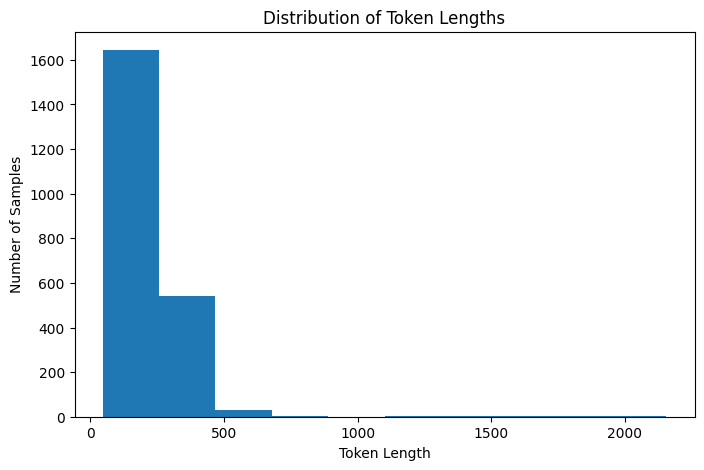

In [18]:
import matplotlib.pyplot as plt

# Compute lengths
lengths = df["embedded_text"].apply(len)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(lengths)
plt.xlabel("Token Length")
plt.ylabel("Number of Samples")
plt.title("Distribution of Token Lengths")
plt.show()


In [19]:
MAX_LEN = 256

def pad_or_trim(seq, max_len=MAX_LEN):
    # If longer → trim
    if len(seq) > max_len:
        return seq[:max_len]
    # If shorter → pad
    return seq + [0] * (max_len - len(seq))

df["padded_embedded"] = df["embedded_text"].apply(pad_or_trim)
df.head()

,Text,Label,cleaned_text,embedded_text,padded_embedded
0,Budget to set scene for election\n \n Gordon B...,0,"[budget, set, scene, election, gordon, brown, ...","[23099, 2137, 4705, 864, 24747, 21121, 3484, 1...","[23099, 2137, 4705, 864, 24747, 21121, 3484, 1..."
1,Army chiefs in regiments decision\n \n Militar...,0,"[army, chiefs, regiments, decision, military, ...","[17244, 818, 18716, 11646, 15990, 818, 9502, 9...","[17244, 818, 18716, 11646, 15990, 818, 9502, 9..."
2,Howard denies split over ID cards\n \n Michael...,0,"[howard, denies, split, id, cards, michael, ho...","[21150, 12305, 25994, 19867, 11051, 1026, 2115...","[21150, 12305, 25994, 19867, 11051, 1026, 2115..."
3,Observers to monitor UK election\n \n Minister...,0,"[observers, monitor, uk, election, ministers, ...","[26130, 14262, 25878, 864, 25980, 14572, 2155,...","[26130, 14262, 25878, 864, 25980, 14572, 2155,..."
4,Kilroy names election seat target\n \n Ex-chat...,0,"[kilroy, names, election, seat, target, show, ...","[20392, 3606, 864, 12635, 9792, 17187, 22049, ...","[20392, 3606, 864, 12635, 9792, 17187, 22049, ..."


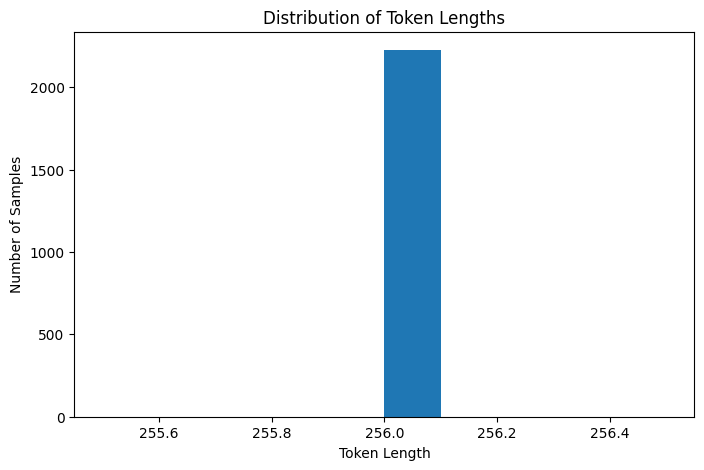

In [20]:
import matplotlib.pyplot as plt

# Compute lengths
lengths = df["padded_embedded"].apply(len)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(lengths)
plt.xlabel("Token Length")
plt.ylabel("Number of Samples")
plt.title("Distribution of Token Lengths")
plt.show()

## **Model building**

### **Transformers**

![Screenshot 2025-11-27 at 21.23.01.png](<attachment:Screenshot 2025-11-27 at 21.23.01.png>)
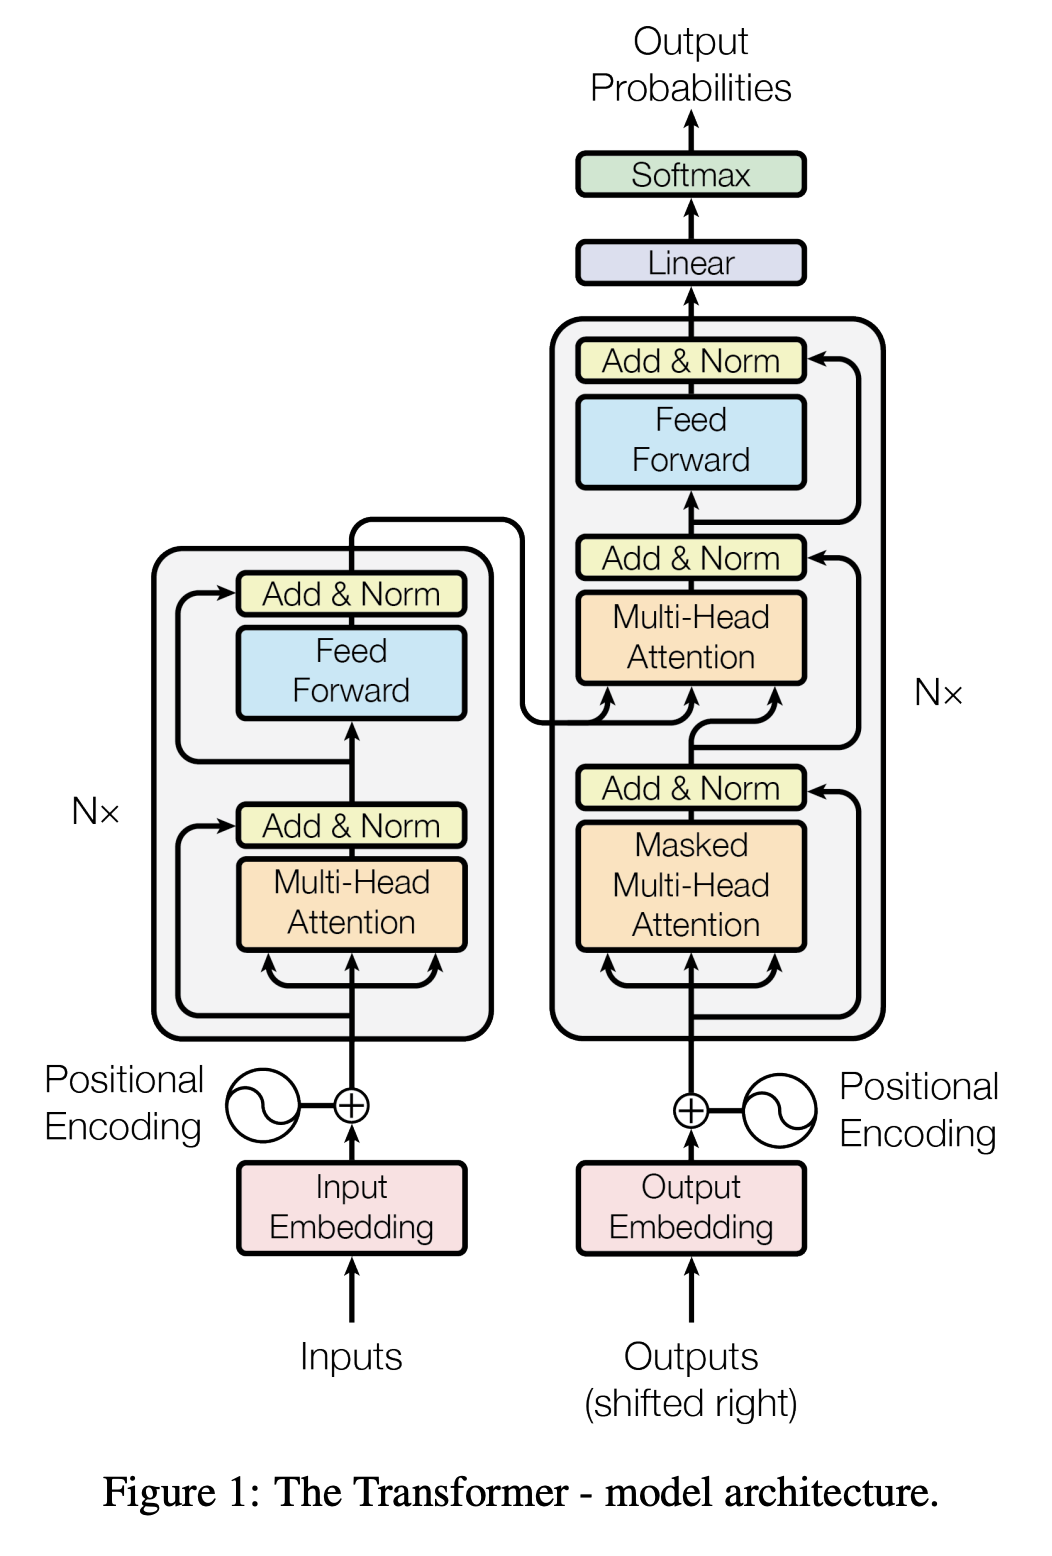

### **Positional Embedding (Trainable)**

In [21]:
import torch
import torch.nn as nn
import math

class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, emb_dim):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_len, emb_dim)

    def forward(self, x):
        # x shape: (batch, seq_len)
        batch, seq_len = x.size()
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        return self.pos_embedding(positions)   # (1, seq_len, emb_dim)


In [22]:
my_positions = PositionalEmbedding(256, 512)
my_inputs = torch.randn(200, 256)
out_pos = my_positions(my_inputs)
print(out_pos.shape)

torch.Size([1, 256, 512])


### **LayerNorm**

In [28]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

### **Multi-Head Attention**

In [29]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0

        self.dim_head = d_model // num_heads
        self.num_heads = num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)

        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        B, L, D = x.size()

        Q = self.q_linear(x)
        K = self.k_linear(x)
        V = self.v_linear(x)

        Q = Q.view(B, L, self.num_heads, self.dim_head).transpose(1, 2)
        K = K.view(B, L, self.num_heads, self.dim_head).transpose(1, 2)
        V = V.view(B, L, self.num_heads, self.dim_head).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.dim_head)
        attn = torch.softmax(scores, dim=-1)
        attn = self.dropout(attn)

        out = attn @ V
        out = out.transpose(1, 2).reshape(B, L, D)

        return self.out_proj(out)


### **Feed Forward**

In [30]:
class FeedForwardNN(nn.Module):
    def __init__(self, d_model, d_ff=512, dropout=0.1):
        super(FeedForwardNN, self).__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x


### **Transformer Block (Encoder Block)**

In [31]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff=512, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = FeedForwardNN(d_model, d_ff, dropout)

        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out = self.attn(x)
        x = self.norm1(x + self.dropout(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x


### **Complete Transformer Model for Text Classification**

In [32]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, max_len, d_model=512,
                 num_heads=4, num_classes=5, num_layers=1):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = PositionalEmbedding(max_len, d_model)

        self.layers = nn.ModuleList([
            TransformerBlock(d_model, num_heads) for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):  # x: (batch, seq_len)
        tok = self.token_emb(x)                      # (B, L, d)
        pos = self.pos_emb(x)                       # (1, L, d)
        out = tok + pos

        for layer in self.layers:
            out = layer(out)

        cls_token = out[:, 0, :]                    # take first token for classification

        return self.classifier(cls_token)


In [33]:
vocab_size = len(word2idx)

model = TransformerClassifier(vocab_size, max_len=256, 
                              d_model=512, num_heads=4, 
                              num_classes=5, num_layers=1)

total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable_params)


Total parameters: 15641605
Trainable parameters: 15641605


In [34]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

X = df["padded_embedded"].tolist()   # list of lists
y = df["Label"].tolist()             # labels

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", len(X_train), "Test size:", len(X_test))
print("Input shape:", X_train.shape)

Train size: 1780 Test size: 445
Input shape: (1780, 256)


In [35]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 32

train_dataset = TextDataset(X_train, y_train)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [36]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Using device: mps


In [37]:
epochs = 10
losses = []
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)       # (batch, num_classes)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")


Epoch 1/10, Loss: 1.5278
Epoch 2/10, Loss: 1.0587
Epoch 3/10, Loss: 0.6354
Epoch 4/10, Loss: 0.3279
Epoch 5/10, Loss: 0.1721
Epoch 6/10, Loss: 0.0930
Epoch 7/10, Loss: 0.0455
Epoch 8/10, Loss: 0.0277
Epoch 9/10, Loss: 0.0205
Epoch 10/10, Loss: 0.0182


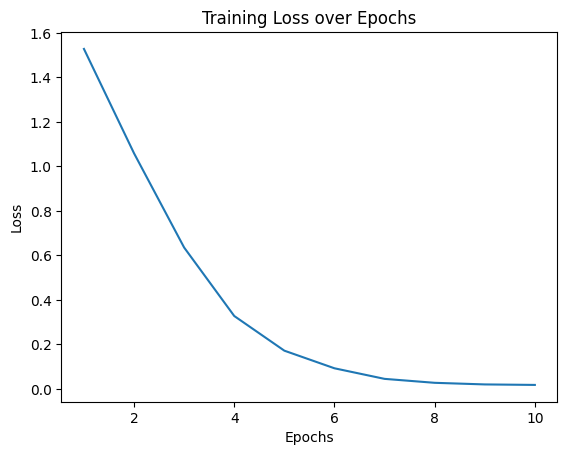

In [38]:
plt.plot(range(1, epochs+1), losses)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss over Epochs")
plt.show()

In [39]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.8652


In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = model(batch_x)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)


In [41]:
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.83      0.89        84
           1       0.88      0.92      0.90       102
           2       0.85      0.88      0.86        80
           3       0.82      0.83      0.83        77
           4       0.84      0.85      0.84       102

    accuracy                           0.87       445
   macro avg       0.87      0.86      0.86       445
weighted avg       0.87      0.87      0.87       445



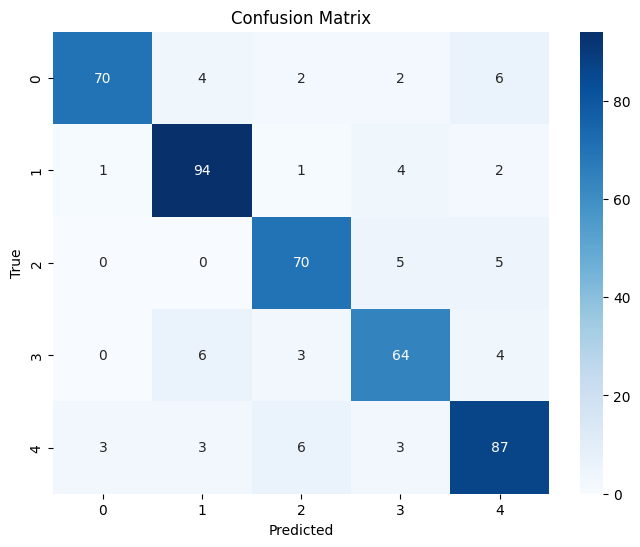

In [42]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [43]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

# Step 3: Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    # "Support Vector Machine (SVM)": SVC(kernel='linear', probability=True),
    "Naive Bayes": MultinomialNB(),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    # "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Step 4: Train and evaluate each model
results = {}
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Predict on test set
    accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
    results[model_name] = accuracy  # Store accuracy for comparison
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

# Step 5: Display model performance comparison
print("\nModel Performance Comparison:")
for model_name, accuracy in results.items():
    print(f"{model_name}: {accuracy:.4f}")



Training Logistic Regression...


/Users/oybekeraliev/Desktop/my_project/my_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.3101
              precision    recall  f1-score   support

           0       0.32      0.24      0.27        84
           1       0.31      0.32      0.32       102
           2       0.36      0.40      0.38        80
           3       0.31      0.31      0.31        77
           4       0.27      0.28      0.28       102

    accuracy                           0.31       445
   macro avg       0.31      0.31      0.31       445
weighted avg       0.31      0.31      0.31       445


Training Naive Bayes...
Naive Bayes Accuracy: 0.3326
              precision    recall  f1-score   support

           0       0.38      0.07      0.12        84
           1       0.48      0.32      0.39       102
           2       0.29      0.56      0.38        80
           3       0.29      0.57      0.39        77
           4       0.36      0.20      0.25       102

    accuracy                           0.33       445
   macro avg       0.36      0.34      0